# Multitask Shapes – interactive play  
  
This notebook lets you **play the customised “Multitask Shapes” environment** that you pasted.  
At each step you’ll be asked for an action:

| index | meaning  |
|-------|----------|
| 0     | **UP**   |
| 1     | **DOWN** |
| 2     | **LEFT** |
| 3     | **RIGHT**|
| 4     | **PICK** |
| 5     | **DROP** |

The notebook will  
* execute the action,  
* print the new reward & raw observation, and  
* display the rendered frame.

> **Prerequisites**  
> * `shapes.py`, `multitask_shapes.py`, `utils.py`, the `assets/` folder and your YAML hyper‑parameter file must be provided.
> * Python ≥ 3.9 with the packages in the first code‑cell installed.


In [1]:
# ------------------------------------------------------------
# (Optional) install runtime dependencies
# ------------------------------------------------------------
# If you are missing any of these packages, remove the leading
# '#' and run the cell once.
#
# !pip install -q gymnasium numpy opencv-python-headless matplotlib pyyaml


In [1]:
# ------------------------------------------------------------
# Imports & utility helpers
# ------------------------------------------------------------
import os, yaml, numpy as np, cv2, matplotlib.pyplot as plt
from typing import Dict
from IPython.display import clear_output
import time

# Adjust the import below if your python file has a different name
from envs.shapes.shapes import ShapesRetrieve, ShapesTerminal, ShapesGoto, DEFAULT_DOORS, DEFAULT_OBJECTS, RND_FTR_RNG
from utils import setup_artefact_paths

N_CNFD_VARS = 1

# Helper to display a rendered frame inline
def show_frame(img):
    plt.figure(figsize=(4,4))
    # convert BGR (OpenCV) ➜ RGB (matplotlib)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

def _category_range(features: Dict, category: str) -> int:
    rng = len(features[category])
    if category == "shape" and "door" in features[category]:
        rng -= 1
    return rng

def obs_layout_from_featureset(
    obs_size: int,
    features: Dict,
    n_objs: int,
    n_doors: int,
    n_cnfd_vars: int,
    featureset_id: int,
    has_terminal_loc: bool,
):
    colour_rng = _category_range(features, "colour")
    shape_rng = _category_range(features, "shape")

    num_obj_ftrs = 2 + colour_rng + shape_rng + 1 + n_cnfd_vars * RND_FTR_RNG
    num_door_ftrs = 2 + colour_rng + 1 + n_cnfd_vars * RND_FTR_RNG

    door_start_idx = n_objs * num_obj_ftrs
    agent_start_idx = door_start_idx + n_doors * num_door_ftrs
    base_obs_size = agent_start_idx + 2

    if obs_size < base_obs_size:
        raise ValueError(
            f"Observation size {obs_size} is too small for expected one-hot base size {base_obs_size}."
        )

    semantic_size = obs_size - base_obs_size

    if featureset_id == 0:
        if semantic_size != 0:
            raise ValueError(
                f"FEATURESET_ID=0 expects no semantic tail, but found {semantic_size} extra values."
            )
        has_semantic_features = False
        semantic_random_ftrs = 0
    elif featureset_id == 1:
        has_semantic_features = True
        semantic_min_size = 1 + int(has_terminal_loc) + colour_rng + shape_rng
        semantic_random_total = n_cnfd_vars * RND_FTR_RNG

        if semantic_size < semantic_min_size:
            raise ValueError(
                f"FEATURESET_ID=1 semantic tail is too short: got {semantic_size}, need at least {semantic_min_size}."
            )

        semantic_extra = semantic_size - semantic_min_size
        if semantic_extra == 0:
            semantic_random_ftrs = 0
        elif semantic_extra == semantic_random_total:
            semantic_random_ftrs = n_cnfd_vars
        else:
            raise ValueError(
                "Unexpected FEATURESET_ID=1 semantic tail size. "
                f"Got {semantic_size}, expected {semantic_min_size} or {semantic_min_size + semantic_random_total}."
            )
    else:
        raise ValueError(f"Unsupported FEATURESET_ID={featureset_id}. Use 0 or 1.")

    return {
        "colour_rng": colour_rng,
        "shape_rng": shape_rng,
        "num_obj_ftrs": num_obj_ftrs,
        "num_door_ftrs": num_door_ftrs,
        "n_objs": n_objs,
        "n_doors": n_doors,
        "n_cnfd_vars": n_cnfd_vars,
        "door_start_idx": door_start_idx,
        "agent_start_idx": agent_start_idx,
        "base_obs_size": base_obs_size,
        "has_semantic_features": has_semantic_features,
        "has_terminal_loc": has_terminal_loc,
        "semantic_random_ftrs": semantic_random_ftrs,
    }

def _decode_onehot(vec: np.ndarray, idx: int, width: int):
    segment = vec[idx:idx + width]
    if segment.size != width:
        raise ValueError(f"Cannot decode one-hot segment of width {width} at idx {idx}.")
    if np.count_nonzero(segment) == 0:
        return None, idx + width
    return int(np.argmax(segment)), idx + width

def _decode_random_feature_block(vec: np.ndarray, idx: int, n_cnfd_vars: int):
    decoded = []
    for _ in range(n_cnfd_vars):
        rnd_val, idx = _decode_onehot(vec, idx, RND_FTR_RNG)
        decoded.append(rnd_val)
    return decoded, idx

def semantically_interpretable_state(obs: np.ndarray, features: Dict, layout: Dict):
    base_obs = obs[:layout["base_obs_size"]]

    door_idx_0 = layout["door_start_idx"]
    agent_idx_0 = layout["agent_start_idx"]
    num_obj_ftrs = layout["num_obj_ftrs"]
    num_door_ftrs = layout["num_door_ftrs"]
    num_objs = layout["n_objs"]
    num_doors = layout["n_doors"]
    n_cnfd_vars = layout["n_cnfd_vars"]

    print(f"Agent is at {base_obs[agent_idx_0]}, {base_obs[agent_idx_0+1]}.")

    obj_rows = base_obs[:door_idx_0].reshape(num_objs, num_obj_ftrs)
    for obj_row in obj_rows:
        obj_x = int(obj_row[0])
        obj_y = int(obj_row[1])

        cursor = 2
        obj_clr_idx, cursor = _decode_onehot(obj_row, cursor, layout["colour_rng"])
        obj_shape_idx, cursor = _decode_onehot(obj_row, cursor, layout["shape_rng"])

        obj_picked_up = int(obj_row[cursor])
        cursor += 1

        obj_random_vals, cursor = _decode_random_feature_block(obj_row, cursor, n_cnfd_vars)

        obj_clr_str = features["colour"][obj_clr_idx] if obj_clr_idx is not None else "none"
        obj_shape_str = features["shape"][obj_shape_idx] if obj_shape_idx is not None else "none"

        semantic_str = f"{obj_clr_str} {obj_shape_str} at {obj_x}, {obj_y}."
        if obj_random_vals:
            semantic_str += f" random={obj_random_vals}."
        if obj_picked_up:
            semantic_str += " Object in inventory."
        print(semantic_str)

    door_rows = base_obs[door_idx_0:agent_idx_0].reshape(num_doors, num_door_ftrs)
    for door_row in door_rows:
        door_x = int(door_row[0])
        door_y = int(door_row[1])

        cursor = 2
        door_clr_idx, cursor = _decode_onehot(door_row, cursor, layout["colour_rng"])

        door_locked = int(door_row[cursor])
        cursor += 1

        door_random_vals, cursor = _decode_random_feature_block(door_row, cursor, n_cnfd_vars)

        door_clr_str = features["colour"][door_clr_idx] if door_clr_idx is not None else "none"
        semantic_str = f"{door_clr_str} door at {door_x}, {door_y} is "
        semantic_str += "locked." if door_locked else "unlocked."
        if door_random_vals:
            semantic_str += f" random={door_random_vals}."
        print(semantic_str)

    if not layout["has_semantic_features"]:
        return

    semantic_obs = obs[layout["base_obs_size"]:]
    cursor = 0

    bias, cursor = int(semantic_obs[cursor]), cursor + 1
    print(f"Semantic bias: {bias}")

    if layout["has_terminal_loc"]:
        at_terminal, cursor = int(semantic_obs[cursor]), cursor + 1
        print(f"Semantic at terminal: {at_terminal}")

    semantic_colour_idx, cursor = _decode_onehot(semantic_obs, cursor, layout["colour_rng"])
    semantic_shape_idx, cursor = _decode_onehot(semantic_obs, cursor, layout["shape_rng"])

    semantic_colour_str = features["colour"][semantic_colour_idx] if semantic_colour_idx is not None else "none"
    semantic_shape_str = features["shape"][semantic_shape_idx] if semantic_shape_idx is not None else "none"

    print(f"Semantic colour: {semantic_colour_str}")
    print(f"Semantic shape: {semantic_shape_str}")

    if layout["semantic_random_ftrs"] > 0:
        semantic_random_vals, cursor = _decode_random_feature_block(
            semantic_obs, cursor, layout["semantic_random_ftrs"]
        )
        print(f"Semantic random features: {semantic_random_vals}")


/home/djordje/miniconda3/envs/rlexp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ------------------------------------------------------------
# Load hyper‑parameters & create the environment
# ------------------------------------------------------------
parent_dir = os.path.dirname(os.getcwd())
# Fill yaml_path as desired, the rest should work as is.
yaml_path = os.path.join(parent_dir, "envs", "shapes", "configs", "shapes.yaml")

FEATURESET_ID = 1

script_path = os.path.join(os.getcwd(), 'shapes_play.ipynb')
store_path, _ = setup_artefact_paths(script_path)

with open(yaml_path, 'r') as f:
    hparams = yaml.safe_load(f)

hparams = hparams["environment"] if "environment" in hparams else hparams
env = ShapesGoto(
    objects=DEFAULT_OBJECTS,
    doors=DEFAULT_DOORS,
    grid=hparams["grid"],
    features=hparams["features"],
    store_path=store_path,
    max_steps=hparams["max_steps"],
    featureset_id=FEATURESET_ID,
    n_confound_ftrs=N_CNFD_VARS
)
# env = ShapesTerminal(
#     desireable_obj=DEFAULT_OBJECTS[0],
#     spawned_objects=DEFAULT_OBJECTS,
#     doors=DEFAULT_DOORS,
#     grid=hparams["grid"],
#     features=hparams["features"],
#     store_path=store_path,
#     max_steps=hparams["max_steps"],
#     featureset_id=FEATURESET_ID,
#     n_confound_ftrs=N_CNFD_VARS
# )
print('Environment ready ✔')


Environment ready ✔


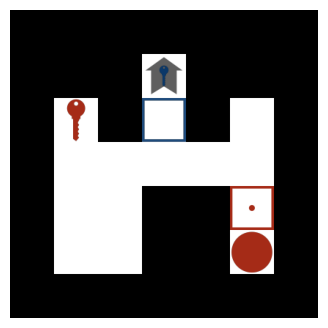

Episode finished.
Current observation: [0 0 0 0 0 0 0 0 0 0 1 2 1 1 0 0 0 0 1 0 1 0 1 3 0 1 0 0 0 1 1 1 0 5 5 1 0
 0 0 1 0 0 1 0 2 3 0 1 0 0 0 0 1 4 5 1 0 0 0 1 0 1 1 3 1 0 0 1 0 0 1 0 0 1]
Agent is at 1, 3.
none none at 0, 0. random=[1].
red key at 2, 1. random=[0].
blue key at 1, 3. random=[0]. Object in inventory.
red ball at 5, 5. random=[0].
blue door at 2, 3 is unlocked. random=[1].
red door at 4, 5 is locked. random=[1].
Semantic bias: 1
Semantic at terminal: 0
Semantic colour: blue
Semantic shape: ball
Semantic random features: [1]
Total steps: 14   Return: -12


In [3]:
# ---- initial reset ----
obs, _ = env.reset()
step = 0
total_reward = 0
last_reward = None          # stores reward from previous step
terminated = truncated = False

layout = obs_layout_from_featureset(
    obs_size=obs.size,
    features=hparams["features"],
    n_objs=env.map.n_objects,
    n_doors=env.map.n_doors,
    n_cnfd_vars=N_CNFD_VARS,
    featureset_id=FEATURESET_ID,
    has_terminal_loc=env.terminal_map_loc is not None,
)
door_start_idx = layout["door_start_idx"]
agent_start_idx = layout["agent_start_idx"]

while not (terminated or truncated):
    clear_output(wait=True)

    # -------- show current frame ----------
    frame = env.render_frame()
    show_frame(frame)

    # -------- show textual info -----------
    print(f"Step: {step}")
    print(f"Return so far: {total_reward}")
    if last_reward is not None:
        print(f"Reward from previous action: {last_reward}")
    print(f"Current observation: {obs}")
    semantically_interpretable_state(obs=obs, features=hparams["features"], layout=layout)
    
    print("Choose action – 0:UP  1:DOWN  2:LEFT  3:RIGHT  4:PICK UP  5:DROP 6:USE")

    # -------- get action ------------------
    action = int(input("Your action index: ").strip())
    if action not in range(7):
        print("❌  Please enter an integer 0‑6.")
        break   

    # -------- environment step ------------
    next_obs, reward, terminated, truncated, _ = env.step(action)

    # update bookkeeping
    last_reward = reward
    total_reward += reward
    obs = next_obs
    step += 1

# final display
clear_output(wait=True)
frame = env.render_frame()
show_frame(frame)
print("Episode finished.")
print(f"Current observation: {obs}")
semantically_interpretable_state(obs=obs, features=hparams["features"], layout=layout)
print(f"Total steps: {step}   Return: {total_reward}")